# Proyecto Final

#### Análisis exploratorio, ingeniería de variables y construcción de una TAD sobre vuelos comerciales en Estados Unidos durante 2024

Objetivo:
Analizar el comportamiento de los vuelos comerciales realizados en Estados Unidos durante el año 2024 mediante técnicas de exploración, limpieza, transformación e ingeniería de datos, con el fin de identificar las aerolíneas y aeropuertos con mayores problemas de puntualidad, así como analizar la influencia de factores temporales sobre los retrasos de los vuelos.

Descripción:
El conjunto de datos contiene información correspondiente a vuelos comerciales operados en Estados Unidos durante el año 2024. Cada registro representa un vuelo e incluye información relacionada con la aerolínea, aeropuertos de origen y destino, horarios programados y reales, duración del vuelo, distancia recorrida, cancelaciones, desvíos y diferentes causas de retraso.

## Librerías

In [2]:
import pandas as pd
import numpy as np
import os

## Carga de datos


In [3]:
df = pd.read_csv('DatasetProject/flight_data_2024_data_dictionary.csv')

In [4]:
df.head()

,column,dtype,null_pct,example_value
0,year,Int64,0.0,2024
1,month,Int64,0.0,1
2,day_of_month,Int64,0.0,1
3,day_of_week,Int64,0.0,1
4,fl_date,datetime64[ns],0.0,2024-01-01 00:00:00


In [5]:
df = pd.read_csv('DatasetProject/flight_data_2024_sample.csv')

In [6]:
df.shape

(10000, 35)

In [7]:
df = pd.read_csv('DatasetProject/flight_data_2024.csv', low_memory=False)

In [8]:
df.shape

(7079081, 35)

Como podemos ver el dataset cuenta con muchos registros y por cuestiones de rendimiento no podemos procesar todo el dataset es por ello
que se decidió que la mejor forma para trabajarlo es tomar un muestra del dataset para continuar con el resto del análisis.

In [9]:
df_muestra = ( df.sample(n=500000, random_state=42) .reset_index(drop=True))

In [10]:
df_muestra.shape

(500000, 35)

## Exploración de los datos

In [11]:
df_muestra.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [12]:
df_muestra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 500000 non-null  int64  
 1   month                500000 non-null  int64  
 2   day_of_month         500000 non-null  int64  
 3   day_of_week          500000 non-null  int64  
 4   fl_date              500000 non-null  object 
 5   op_unique_carrier    500000 non-null  object 
 6   op_carrier_fl_num    500000 non-null  float64
 7   origin               500000 non-null  object 
 8   origin_city_name     500000 non-null  object 
 9   origin_state_nm      500000 non-null  object 
 10  dest                 500000 non-null  object 
 11  dest_city_name       500000 non-null  object 
 12  dest_state_nm        500000 non-null  object 
 13  crs_dep_time         500000 non-null  int64  
 14  dep_time             493480 non-null  float64
 15  dep_delay        

In [13]:
df_muestra.isna().sum() 

year                        0
month                       0
day_of_month                0
day_of_week                 0
fl_date                     0
op_unique_carrier           0
op_carrier_fl_num           0
origin                      0
origin_city_name            0
origin_state_nm             0
dest                        0
dest_city_name              0
dest_state_nm               0
crs_dep_time                0
dep_time                 6520
dep_delay                6543
taxi_out                 6752
wheels_off               6752
wheels_on                6923
taxi_in                  6923
crs_arr_time                0
arr_time                 6923
arr_delay                8027
cancelled                   0
cancellation_code      493189
diverted                    0
crs_elapsed_time            0
actual_elapsed_time      8027
air_time                 8027
distance                    0
carrier_delay               0
weather_delay               0
nas_delay                   0
security_d

In [14]:
df_muestra.duplicated().sum()

np.int64(0)

In [15]:
for c in df_muestra.columns:
    print(c, df_muestra[c].map(type).unique().tolist())

year [<class 'int'>]
month [<class 'int'>]
day_of_month [<class 'int'>]
day_of_week [<class 'int'>]
fl_date [<class 'str'>]
op_unique_carrier [<class 'str'>]
op_carrier_fl_num [<class 'float'>]
origin [<class 'str'>]
origin_city_name [<class 'str'>]
origin_state_nm [<class 'str'>]
dest [<class 'str'>]
dest_city_name [<class 'str'>]
dest_state_nm [<class 'str'>]
crs_dep_time [<class 'int'>]
dep_time [<class 'float'>]
dep_delay [<class 'float'>]
taxi_out [<class 'float'>]
wheels_off [<class 'float'>]
wheels_on [<class 'float'>]
taxi_in [<class 'float'>]
crs_arr_time [<class 'int'>]
arr_time [<class 'float'>]
arr_delay [<class 'float'>]
cancelled [<class 'int'>]
cancellation_code [<class 'float'>, <class 'str'>]
diverted [<class 'int'>]
crs_elapsed_time [<class 'float'>]
actual_elapsed_time [<class 'float'>]
air_time [<class 'float'>]
distance [<class 'float'>]
carrier_delay [<class 'int'>]
weather_delay [<class 'int'>]
nas_delay [<class 'int'>]
security_delay [<class 'int'>]
late_aircraf

In [16]:
df_muestra['cancellation_code'].value_counts(dropna=False)

cancellation_code
NaN    493189
B        3808
A        2186
C         817
Name: count, dtype: int64

In [17]:
df_muestra.describe(percentiles=np.arange(0.90,1,0.01))

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,500000.0,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,493480.000000,493457.000000,493248.000000,493248.00000,...,500000.000000,500000.000000,491973.000000,491973.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,2024.0,6.594700,15.786864,3.979908,2507.508810,1326.244744,1329.837203,12.529773,17.910633,1352.92565,...,0.002432,146.839820,141.287471,115.064026,834.485356,4.997322,0.867448,2.791912,0.025608,5.850286
std,0.0,3.397788,8.790886,2.012587,1653.908217,492.623269,508.943954,55.078486,9.671313,511.38634,...,0.049255,72.293747,72.194334,70.272216,595.569272,34.858955,15.682122,15.388556,1.262733,30.377999
min,2024.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-46.000000,1.000000,1.00000,...,0.000000,22.000000,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2024.0,7.000000,16.000000,4.000000,2229.000000,1320.000000,1324.000000,-2.000000,15.000000,1337.00000,...,0.000000,130.000000,125.000000,98.000000,680.000000,0.000000,0.000000,0.000000,0.000000,0.000000
90%,2024.0,11.000000,28.000000,7.000000,5132.000000,2010.000000,2027.000000,43.000000,28.000000,2042.00000,...,0.000000,247.000000,241.000000,213.000000,1660.000000,3.000000,0.000000,1.000000,0.000000,4.000000
91%,2024.0,11.000000,28.000000,7.000000,5222.000000,2025.000000,2041.000000,49.000000,29.000000,2055.00000,...,0.000000,255.000000,250.000000,221.000000,1728.000000,6.000000,0.000000,3.000000,0.000000,11.000000
92%,2024.0,12.000000,29.000000,7.000000,5291.000000,2040.000000,2053.000000,55.000000,30.000000,2108.00000,...,0.000000,265.000000,259.000000,230.000000,1781.000000,9.000000,0.000000,6.000000,0.000000,16.000000
93%,2024.0,12.000000,29.000000,7.000000,5357.000000,2055.000000,2106.000000,62.000000,31.000000,2121.00000,...,0.000000,276.000000,270.000000,241.000000,1927.000000,13.000000,0.000000,10.000000,0.000000,21.000000
94%,2024.0,12.000000,29.000000,7.000000,5427.000000,2105.000000,2121.000000,71.000000,33.000000,2136.00000,...,0.000000,290.000000,283.000000,254.000000,2039.000000,17.000000,0.000000,15.000000,0.000000,27.000000


In [18]:
## Aqui se puede observar que las columnas dep_time, arr_time, air_time y actual_elapsed_time tienen valores nulos cuando el vuelo 
# fue cancelado. Esto es consistente con la lógica de que si un vuelo es cancelado, no habrá tiempos de salida o llegada, 
# ni tiempo de vuelo ni tiempo transcurrido real. Por lo tanto no podemos imputar estos valores.
df.loc[
    df['cancelled'] == 1,
    [
        'dep_time',
        'arr_time',
        'air_time',
        'actual_elapsed_time'
    ]
].isnull().mean()*100

dep_time                96.204122
arr_time               100.000000
air_time               100.000000
actual_elapsed_time    100.000000
dtype: float64

## Limpieza y transformación 

In [19]:
pd.set_option('display.max_columns', None)

In [20]:
df_muestra.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [21]:
## Convertimos las columnas de fecha a tipo datetime para poder trabajar con ellas de manera más eficiente y realizar análisis de series temporales.
df_muestra['fl_date'] = pd.to_datetime(df_muestra['fl_date'], format= '%Y-%m-%d')

In [22]:
#Convertimos las columnas de tiempo a tipo time.
def convertir_hora(col):
    return pd.to_datetime(
        col.fillna(0)              
           .astype(int)           
           .astype(str)           
           .str.zfill(4),         
        format="%H%M",
        errors="coerce"
    ).dt.time


In [23]:
df_muestra.dtypes

year                            int64
month                           int64
day_of_month                    int64
day_of_week                     int64
fl_date                datetime64[ns]
op_unique_carrier              object
op_carrier_fl_num             float64
origin                         object
origin_city_name               object
origin_state_nm                object
dest                           object
dest_city_name                 object
dest_state_nm                  object
crs_dep_time                    int64
dep_time                      float64
dep_delay                     float64
taxi_out                      float64
wheels_off                    float64
wheels_on                     float64
taxi_in                       float64
crs_arr_time                    int64
arr_time                      float64
arr_delay                     float64
cancelled                       int64
cancellation_code              object
diverted                        int64
crs_elapsed_

In [24]:
time_columns = [
    'crs_dep_time',
    'crs_arr_time',
    'dep_time',
    'arr_time',
    'wheels_off',
    'wheels_on',]
for col in time_columns:
    df_muestra[col] = convertir_hora(df_muestra[col])

In [25]:
df_muestra.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,10:18:00,10:15:00,-3.0,21.0,10:36:00,11:35:00,4.0,11:49:00,11:39:00,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,16:37:00,16:33:00,-4.0,14.0,16:47:00,19:00:00,6.0,19:23:00,19:06:00,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,10:00:00,09:52:00,-8.0,13.0,10:05:00,10:34:00,8.0,10:59:00,10:42:00,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,13:30:00,13:34:00,4.0,8.0,13:42:00,14:25:00,6.0,14:30:00,14:31:00,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,13:40:00,13:33:00,-7.0,16.0,13:49:00,15:05:00,4.0,15:10:00,15:09:00,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [26]:
for col in df_muestra.columns:
    print(col, df_muestra[col].map(type).unique().tolist())

year [<class 'int'>]
month [<class 'int'>]
day_of_month [<class 'int'>]
day_of_week [<class 'int'>]
fl_date [<class 'pandas._libs.tslibs.timestamps.Timestamp'>]
op_unique_carrier [<class 'str'>]
op_carrier_fl_num [<class 'float'>]
origin [<class 'str'>]
origin_city_name [<class 'str'>]
origin_state_nm [<class 'str'>]
dest [<class 'str'>]
dest_city_name [<class 'str'>]
dest_state_nm [<class 'str'>]
crs_dep_time [<class 'datetime.time'>]
dep_time [<class 'datetime.time'>, <class 'pandas._libs.tslibs.nattype.NaTType'>]
dep_delay [<class 'float'>]
taxi_out [<class 'float'>]
wheels_off [<class 'datetime.time'>, <class 'pandas._libs.tslibs.nattype.NaTType'>]
wheels_on [<class 'datetime.time'>, <class 'pandas._libs.tslibs.nattype.NaTType'>]
taxi_in [<class 'float'>]
crs_arr_time [<class 'datetime.time'>]
arr_time [<class 'datetime.time'>, <class 'pandas._libs.tslibs.nattype.NaTType'>]
arr_delay [<class 'float'>]
cancelled [<class 'int'>]
cancellation_code [<class 'float'>, <class 'str'>]
dive

En esta etapa se realizaron las transformaciones necesarias para preparar el conjunto de datos antes del análisis exploratorio y la ingeniería de variables. Se convirtió la variable fl_date al tipo datetime para facilitar el análisis temporal y la creación de ventanas de tiempo. Asimismo, las variables correspondientes a los horarios de salida, llegada, despegue y aterrizaje fueron convertidas a un formato de hora para mejorar su interpretación y permitir la generación de nuevas variables relacionadas con el momento del día.

Adicionalmente, la variable cancellation_code fue convertida a un único tipo de dato para mantener la consistencia del conjunto de datos.

Durante la revisión de valores faltantes se identificó que la mayoría de los registros nulos se concentran en variables operativas del vuelo (hora de salida, llegada, tiempo en aire, entre otras). Tras su análisis, se determinó que estos valores corresponden principalmente a vuelos cancelados, por lo que se decidió conservar dichos registros sin realizar imputaciones, ya que representan una condición válida dentro de la operación aérea.

## Identificar la unidad muestral (UM)

In [27]:
df_muestra.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,10:18:00,10:15:00,-3.0,21.0,10:36:00,11:35:00,4.0,11:49:00,11:39:00,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,16:37:00,16:33:00,-4.0,14.0,16:47:00,19:00:00,6.0,19:23:00,19:06:00,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,10:00:00,09:52:00,-8.0,13.0,10:05:00,10:34:00,8.0,10:59:00,10:42:00,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,13:30:00,13:34:00,4.0,8.0,13:42:00,14:25:00,6.0,14:30:00,14:31:00,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,13:40:00,13:33:00,-7.0,16.0,13:49:00,15:05:00,4.0,15:10:00,15:09:00,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [28]:
df_muestra.reset_index(drop=True, inplace=True)
df_muestra.reset_index(inplace=True)

In [29]:
df_muestra.head()

,index,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,10:18:00,10:15:00,-3.0,21.0,10:36:00,11:35:00,4.0,11:49:00,11:39:00,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,16:37:00,16:33:00,-4.0,14.0,16:47:00,19:00:00,6.0,19:23:00,19:06:00,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,10:00:00,09:52:00,-8.0,13.0,10:05:00,10:34:00,8.0,10:59:00,10:42:00,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,13:30:00,13:34:00,4.0,8.0,13:42:00,14:25:00,6.0,14:30:00,14:31:00,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,13:40:00,13:33:00,-7.0,16.0,13:49:00,15:05:00,4.0,15:10:00,15:09:00,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [30]:
df_muestra['delay'] = (df_muestra['arr_delay'] >= 15).astype(int)

In [31]:
df_muestra.head()

,index,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay
0,0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,10:18:00,10:15:00,-3.0,21.0,10:36:00,11:35:00,4.0,11:49:00,11:39:00,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0,0
1,1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,16:37:00,16:33:00,-4.0,14.0,16:47:00,19:00:00,6.0,19:23:00,19:06:00,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0,0
2,2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,10:00:00,09:52:00,-8.0,13.0,10:05:00,10:34:00,8.0,10:59:00,10:42:00,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0,0
3,3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,13:30:00,13:34:00,4.0,8.0,13:42:00,14:25:00,6.0,14:30:00,14:31:00,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0,0
4,4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,13:40:00,13:33:00,-7.0,16.0,13:49:00,15:05:00,4.0,15:10:00,15:09:00,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0,0


In [32]:
df_muestra['delay'].value_counts()

delay
0    398000
1    102000
Name: count, dtype: int64

In [33]:
um = ['idex']
tgt = ['delay']

## Ingenieria de variables.

* Estación del año: Invierno, Primavera, Verano u Otoño
* Momento de salida programada: Madrugada, Mañana, Tarde o Noche
* 1 si el vuelo es sábado/domingo, 0 si es entre semana
* Diferencia entre duración real y duración programada
* Duración programada del vuelo expresada en horas
* Distancia programada dividida entre duración programada
* 1 si la distancia está por encima o igual a la mediana, 0 en caso contrario
* Número total de vuelos programados ese día
* Número de vuelos programados desde ese aeropuerto en ese día

In [34]:
df_muestra.head()

,index,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay
0,0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,10:18:00,10:15:00,-3.0,21.0,10:36:00,11:35:00,4.0,11:49:00,11:39:00,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0,0
1,1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,16:37:00,16:33:00,-4.0,14.0,16:47:00,19:00:00,6.0,19:23:00,19:06:00,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0,0
2,2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,10:00:00,09:52:00,-8.0,13.0,10:05:00,10:34:00,8.0,10:59:00,10:42:00,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0,0
3,3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,13:30:00,13:34:00,4.0,8.0,13:42:00,14:25:00,6.0,14:30:00,14:31:00,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0,0
4,4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,13:40:00,13:33:00,-7.0,16.0,13:49:00,15:05:00,4.0,15:10:00,15:09:00,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0,0


In [35]:
df_muestra.dtypes

index                           int64
year                            int64
month                           int64
day_of_month                    int64
day_of_week                     int64
fl_date                datetime64[ns]
op_unique_carrier              object
op_carrier_fl_num             float64
origin                         object
origin_city_name               object
origin_state_nm                object
dest                           object
dest_city_name                 object
dest_state_nm                  object
crs_dep_time                   object
dep_time                       object
dep_delay                     float64
taxi_out                      float64
wheels_off                     object
wheels_on                      object
taxi_in                       float64
crs_arr_time                   object
arr_time                       object
arr_delay                     float64
cancelled                       int64
cancellation_code              object
diverted    

In [36]:
df_muestra['temporada'] = df_muestra['month'].map({
    1: 'Invierno', 2: 'Invierno', 3: 'Invierno',
    4: 'Primavera', 5: 'Primavera', 6: 'Primavera',
    7: 'Verano', 8: 'Verano', 9: 'Verano',
    10: 'Otoño', 11: 'Otoño', 12: 'Otoño'
})
df_muestra['crs_dep_time'] = pd.to_datetime(
    df_muestra['crs_dep_time'],
    format='%H:%M:%S',
    errors='coerce'
)

hora = df_muestra['crs_dep_time'].dt.hour

df_muestra['momento_dia'] = pd.cut(
    hora,
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada', 'Mañana', 'Tarde', 'Noche']
)
df_muestra['es_fin_semana'] = np.where(
    df_muestra['day_of_week'].isin([6, 7]),
    1,
    0
)    
df_muestra['dif_tiempo_real_programado'] = (
    df_muestra['actual_elapsed_time'] - df_muestra['crs_elapsed_time']

)
df_muestra['duracion_horas'] = df_muestra['crs_elapsed_time'] / 60

df_muestra['velocidad_programada'] = (
    df_muestra['distance'] / (df_muestra['crs_elapsed_time'] / 60)
)
df_muestra['vuelo_largo'] = np.where(df_muestra['distance'] >= df_muestra['distance'].median(), 1, 0)
df_muestra['vuelos_dia'] = df_muestra.groupby('fl_date')['index'].transform('count')
df_muestra['vuelos_origen_dia'] = (
    df_muestra.groupby(['fl_date', 'origin'])['index']
      .transform('count')
)

In [37]:
# Unidad muestral
um = ['index']

# Variable objetivo
tgt = ['delay']


# Variables categóricas / discretas
varc = [
    'year',
    'month',
    'day_of_month',
    'day_of_week',
    'op_unique_carrier',
    'op_carrier_fl_num',      
    'origin',
    'origin_city_name',
    'origin_state_nm',
    'dest',
    'dest_city_name',
    'dest_state_nm',
    'crs_dep_time',
    'crs_arr_time',
    'temporada',
    'momento_dia',
    'es_fin_semana',
    'vuelo_largo'
]


# Variables numéricas / continuas
vard = [
    'crs_elapsed_time',
    'distance',
    'duracion_horas',
    'velocidad_programada',
    'vuelos_dia',
    'vuelos_origen_dia',
    'dif_tiempo_real_programado'
]


# Variables fuera de la TAD / no utilizar como predictoras
var_fuera = [
    'fl_date',
    'dep_time',
    'dep_delay',
    'taxi_out',
    'wheels_off',
    'wheels_on',
    'taxi_in',
    'arr_time',
    'arr_delay',
    'cancelled',
    'cancellation_code',
    'diverted',
    'actual_elapsed_time',
    'air_time',
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]

Variables fuera: Se excluyeron estas variables debido a que contienen información generada durante o después de la operación del vuelo, como tiempos reales, retrasos, cancelaciones y causas del retraso. Utilizarlas como predictoras provocaría fuga de información, ya que esta información no estaría disponible al momento de realizar la predicción. Por ello, se conservarán únicamente variables que puedan conocerse antes de la salida programada del vuelo.

In [38]:
df_muestra.shape, len(varc),len(vard)

((500000, 46), 18, 7)

In [39]:
df_muestra.dtypes

index                                  int64
year                                   int64
month                                  int64
day_of_month                           int64
day_of_week                            int64
fl_date                       datetime64[ns]
op_unique_carrier                     object
op_carrier_fl_num                    float64
origin                                object
origin_city_name                      object
origin_state_nm                       object
dest                                  object
dest_city_name                        object
dest_state_nm                         object
crs_dep_time                  datetime64[ns]
dep_time                              object
dep_delay                            float64
taxi_out                             float64
wheels_off                            object
wheels_on                             object
taxi_in                              float64
crs_arr_time                          object
arr_time  

In [40]:
for col in vard:
    df_muestra[col] = pd.to_numeric(df_muestra[col], errors='coerce') # Convierte a numérico y ponen NaNs
 
for col in varc:
    df_muestra[col] = df_muestra[col].astype(str)

In [41]:
df_muestra.drop(columns=var_fuera, inplace=True)

In [42]:
df_muestra.shape

(500000, 27)

## Analisis Exploratorio

### Categoricas

In [43]:
def freq(df_muestra, var):
    if type(var) != list:
        var = [var]
    for v in var:
        #v = 'state'
        aux = df_muestra[v].value_counts().to_frame().rename(columns={'count':'FA'})
        aux['FR'] = aux['FA'] / aux['FA'].sum()
        aux[['FAA','FRA']] = aux.apply(  np.cumsum )
        print(f"La variable: {v}")
        display(aux)
        print("\n")

def normalizar(df_muestra, v, umbral):

    aux = df_muestra[v].value_counts(True).to_frame()

    aux[f"n_{v}"] = np.where(
        aux['proportion'] < umbral,
        'CAT_PEQUE',
        aux.index
    )

    moda = aux.head()[f'n_{v}'].values[0]

    if aux.loc[
        aux[f'n_{v}'] == 'CAT_PEQUE'
    ]['proportion'].sum() < umbral:

        aux[f'n_{v}'] = aux[f'n_{v}'].replace(
            {'CAT_PEQUE': moda}
        )

    aux.reset_index(inplace=True)

    return df_muestra.merge(
        aux,
        left_on=[v],
        right_on=[v],
        how='inner'
    ).drop('proportion', axis=1)

In [44]:
freq(df_muestra, varc)

La variable: year


,FA,FR,FAA,FRA
year,,,,
2024,500000,1.0,500000,1.0




La variable: month


,FA,FR,FAA,FRA
month,,,,
7,45372,0.090744,45372,0.090744
10,43925,0.087850,89297,0.178594
8,43293,0.086586,132590,0.265180
5,42999,0.085998,175589,0.351178
6,42923,0.085846,218512,0.437024
12,41847,0.083694,260359,0.520718
3,41687,0.083374,302046,0.604092
9,40986,0.081972,343032,0.686064
4,40970,0.081940,384002,0.768004




La variable: day_of_month


,FA,FR,FAA,FRA
day_of_month,,,,
22,17113,0.034226,17113,0.034226
19,16851,0.033702,33964,0.067928
15,16784,0.033568,50748,0.101496
29,16755,0.033510,67503,0.135006
8,16714,0.033428,84217,0.168434
26,16696,0.033392,100913,0.201826
18,16678,0.033356,117591,0.235182
21,16653,0.033306,134244,0.268488
23,16650,0.033300,150894,0.301788




La variable: day_of_week


,FA,FR,FAA,FRA
day_of_week,,,,
1,76003,0.152006,76003,0.152006
5,74700,0.149400,150703,0.301406
7,74009,0.148018,224712,0.449424
4,73584,0.147168,298296,0.596592
2,69000,0.138000,367296,0.734592
3,68724,0.137448,436020,0.872040
6,63980,0.127960,500000,1.000000




La variable: op_unique_carrier


,FA,FR,FAA,FRA
op_unique_carrier,,,,
WN,100707,0.201414,100707,0.201414
DL,71277,0.142554,171984,0.343968
AA,69307,0.138614,241291,0.482582
UA,53586,0.107172,294877,0.589754
OO,52810,0.105620,347687,0.695374
YX,21241,0.042482,368928,0.737856
MQ,19944,0.039888,388872,0.777744
NK,18404,0.036808,407276,0.814552
AS,17250,0.034500,424526,0.849052




La variable: op_carrier_fl_num


,FA,FR,FAA,FRA
op_carrier_fl_num,,,,
555.0,268,0.000536,268,0.000536
374.0,227,0.000454,495,0.000990
1368.0,220,0.000440,715,0.001430
392.0,219,0.000438,934,0.001868
323.0,217,0.000434,1151,0.002302
...,...,...,...,...
8786.0,1,0.000002,499996,0.999992
6729.0,1,0.000002,499997,0.999994
6403.0,1,0.000002,499998,0.999996




La variable: origin


,FA,FR,FAA,FRA
origin,,,,
ATL,24473,0.048946,24473,0.048946
DFW,22070,0.044140,46543,0.093086
DEN,22011,0.044022,68554,0.137108
ORD,19772,0.039544,88326,0.176652
CLT,15076,0.030152,103402,0.206804
...,...,...,...,...
GST,4,0.000008,499990,0.999980
VEL,3,0.000006,499993,0.999986
CNY,3,0.000006,499996,0.999992




La variable: origin_city_name


,FA,FR,FAA,FRA
origin_city_name,,,,
"Chicago, IL",25473,0.050946,25473,0.050946
"Atlanta, GA",24473,0.048946,49946,0.099892
"Dallas/Fort Worth, TX",22070,0.044140,72016,0.144032
"Denver, CO",22011,0.044022,94027,0.188054
"New York, NY",20159,0.040318,114186,0.228372
...,...,...,...,...
"Gustavus, AK",4,0.000008,499990,0.999980
"Vernal, UT",3,0.000006,499993,0.999986
"Moab, UT",3,0.000006,499996,0.999992




La variable: origin_state_nm


,FA,FR,FAA,FRA
origin_state_nm,,,,
Texas,53434,0.106868,53434,0.106868
California,52052,0.104104,105486,0.210972
Florida,44593,0.089186,150079,0.300158
Illinois,26391,0.052782,176470,0.352940
Georgia,26362,0.052724,202832,0.405664
New York,25819,0.051638,228651,0.457302
Colorado,24672,0.049344,253323,0.506646
North Carolina,22027,0.044054,275350,0.550700
Virginia,16781,0.033562,292131,0.584262




La variable: dest


,FA,FR,FAA,FRA
dest,,,,
ATL,23852,0.047704,23852,0.047704
DFW,22300,0.044600,46152,0.092304
DEN,21811,0.043622,67963,0.135926
ORD,19794,0.039588,87757,0.175514
CLT,15201,0.030402,102958,0.205916
...,...,...,...,...
EAR,6,0.000012,499986,0.999972
DLG,4,0.000008,499990,0.999980
VEL,4,0.000008,499994,0.999988




La variable: dest_city_name


,FA,FR,FAA,FRA
dest_city_name,,,,
"Chicago, IL",25470,0.050940,25470,0.050940
"Atlanta, GA",23852,0.047704,49322,0.098644
"Dallas/Fort Worth, TX",22300,0.044600,71622,0.143244
"Denver, CO",21811,0.043622,93433,0.186866
"New York, NY",20117,0.040234,113550,0.227100
...,...,...,...,...
"Kearney, NE",6,0.000012,499986,0.999972
"Dillingham, AK",4,0.000008,499990,0.999980
"Vernal, UT",4,0.000008,499994,0.999988




La variable: dest_state_nm


,FA,FR,FAA,FRA
dest_state_nm,,,,
Texas,53595,0.107190,53595,0.107190
California,52629,0.105258,106224,0.212448
Florida,44052,0.088104,150276,0.300552
Illinois,26455,0.052910,176731,0.353462
New York,25770,0.051540,202501,0.405002
Georgia,25736,0.051472,228237,0.456474
Colorado,24571,0.049142,252808,0.505616
North Carolina,22116,0.044232,274924,0.549848
Virginia,16838,0.033676,291762,0.583524




La variable: crs_dep_time


,FA,FR,FAA,FRA
crs_dep_time,,,,
1900-01-01 06:00:00,11030,0.022060,11030,0.022060
1900-01-01 07:00:00,8422,0.016844,19452,0.038904
1900-01-01 08:00:00,4716,0.009432,24168,0.048336
1900-01-01 09:00:00,3489,0.006978,27657,0.055314
1900-01-01 06:30:00,3125,0.006250,30782,0.061564
...,...,...,...,...
1900-01-01 04:10:00,1,0.000002,499996,0.999992
1900-01-01 04:39:00,1,0.000002,499997,0.999994
1900-01-01 01:03:00,1,0.000002,499998,0.999996




La variable: crs_arr_time


,FA,FR,FAA,FRA
crs_arr_time,,,,
23:59:00,2383,0.004766,2383,0.004766
20:00:00,1607,0.003214,3990,0.007980
21:50:00,1593,0.003186,5583,0.011166
22:00:00,1589,0.003178,7172,0.014344
17:50:00,1404,0.002808,8576,0.017152
...,...,...,...,...
01:44:00,1,0.000002,499996,0.999992
03:24:00,1,0.000002,499997,0.999994
04:17:00,1,0.000002,499998,0.999996




La variable: temporada


,FA,FR,FAA,FRA
temporada,,,,
Verano,129651,0.259302,129651,0.259302
Primavera,126892,0.253784,256543,0.513086
Otoño,126676,0.253352,383219,0.766438
Invierno,116781,0.233562,500000,1.000000




La variable: momento_dia


,FA,FR,FAA,FRA
momento_dia,,,,
Mañana,194547,0.389094,194547,0.389094
Tarde,177358,0.354716,371905,0.743810
Noche,112677,0.225354,484582,0.969164
Madrugada,15418,0.030836,500000,1.000000




La variable: es_fin_semana


,FA,FR,FAA,FRA
es_fin_semana,,,,
0,362011,0.724022,362011,0.724022
1,137989,0.275978,500000,1.000000




La variable: vuelo_largo


,FA,FR,FAA,FRA
vuelo_largo,,,,
1,250616,0.501232,250616,0.501232
0,249384,0.498768,500000,1.000000


In [45]:
df_muestra.shape

(500000, 27)

In [46]:
umbral = 0.03
for v in varc:
    df_muestra = normalizar(df_muestra, v, umbral)

In [47]:
varn = [col for col in df_muestra.columns if col.startswith('n_')]

In [48]:
varn

['n_year',
 'n_month',
 'n_day_of_month',
 'n_day_of_week',
 'n_op_unique_carrier',
 'n_op_carrier_fl_num',
 'n_origin',
 'n_origin_city_name',
 'n_origin_state_nm',
 'n_dest',
 'n_dest_city_name',
 'n_dest_state_nm',
 'n_crs_dep_time',
 'n_crs_arr_time',
 'n_temporada',
 'n_momento_dia',
 'n_es_fin_semana',
 'n_vuelo_largo']

In [49]:
df.shape

(7079081, 35)

In [50]:
freq(df_muestra, varn)

La variable: n_year


,FA,FR,FAA,FRA
n_year,,,,
2024,500000,1.0,500000,1.0




La variable: n_month


,FA,FR,FAA,FRA
n_month,,,,
7,45372,0.090744,45372,0.090744
10,43925,0.087850,89297,0.178594
8,43293,0.086586,132590,0.265180
5,42999,0.085998,175589,0.351178
6,42923,0.085846,218512,0.437024
12,41847,0.083694,260359,0.520718
3,41687,0.083374,302046,0.604092
9,40986,0.081972,343032,0.686064
4,40970,0.081940,384002,0.768004




La variable: n_day_of_month


,FA,FR,FAA,FRA
n_day_of_month,,,,
22,26235,0.052470,26235,0.052470
19,16851,0.033702,43086,0.086172
15,16784,0.033568,59870,0.119740
29,16755,0.033510,76625,0.153250
8,16714,0.033428,93339,0.186678
26,16696,0.033392,110035,0.220070
18,16678,0.033356,126713,0.253426
21,16653,0.033306,143366,0.286732
23,16650,0.033300,160016,0.320032




La variable: n_day_of_week


,FA,FR,FAA,FRA
n_day_of_week,,,,
1,76003,0.152006,76003,0.152006
5,74700,0.149400,150703,0.301406
7,74009,0.148018,224712,0.449424
4,73584,0.147168,298296,0.596592
2,69000,0.138000,367296,0.734592
3,68724,0.137448,436020,0.872040
6,63980,0.127960,500000,1.000000




La variable: n_op_unique_carrier


,FA,FR,FAA,FRA
n_op_unique_carrier,,,,
WN,100707,0.201414,100707,0.201414
DL,71277,0.142554,171984,0.343968
AA,69307,0.138614,241291,0.482582
UA,53586,0.107172,294877,0.589754
OO,52810,0.105620,347687,0.695374
CAT_PEQUE,42508,0.085016,390195,0.780390
YX,21241,0.042482,411436,0.822872
MQ,19944,0.039888,431380,0.862760
NK,18404,0.036808,449784,0.899568




La variable: n_op_carrier_fl_num


,FA,FR,FAA,FRA
n_op_carrier_fl_num,,,,
CAT_PEQUE,500000,1.0,500000,1.0




La variable: n_origin


,FA,FR,FAA,FRA
n_origin,,,,
CAT_PEQUE,396598,0.793196,396598,0.793196
ATL,24473,0.048946,421071,0.842142
DFW,22070,0.044140,443141,0.886282
DEN,22011,0.044022,465152,0.930304
ORD,19772,0.039544,484924,0.969848
CLT,15076,0.030152,500000,1.000000




La variable: n_origin_city_name


,FA,FR,FAA,FRA
n_origin_city_name,,,,
CAT_PEQUE,370738,0.741476,370738,0.741476
"Chicago, IL",25473,0.050946,396211,0.792422
"Atlanta, GA",24473,0.048946,420684,0.841368
"Dallas/Fort Worth, TX",22070,0.044140,442754,0.885508
"Denver, CO",22011,0.044022,464765,0.929530
"New York, NY",20159,0.040318,484924,0.969848
"Charlotte, NC",15076,0.030152,500000,1.000000




La variable: n_origin_state_nm


,FA,FR,FAA,FRA
n_origin_state_nm,,,,
CAT_PEQUE,192057,0.384114,192057,0.384114
Texas,53434,0.106868,245491,0.490982
California,52052,0.104104,297543,0.595086
Florida,44593,0.089186,342136,0.684272
Illinois,26391,0.052782,368527,0.737054
Georgia,26362,0.052724,394889,0.789778
New York,25819,0.051638,420708,0.841416
Colorado,24672,0.049344,445380,0.890760
North Carolina,22027,0.044054,467407,0.934814




La variable: n_dest


,FA,FR,FAA,FRA
n_dest,,,,
CAT_PEQUE,397042,0.794084,397042,0.794084
ATL,23852,0.047704,420894,0.841788
DFW,22300,0.044600,443194,0.886388
DEN,21811,0.043622,465005,0.930010
ORD,19794,0.039588,484799,0.969598
CLT,15201,0.030402,500000,1.000000




La variable: n_dest_city_name


,FA,FR,FAA,FRA
n_dest_city_name,,,,
CAT_PEQUE,371249,0.742498,371249,0.742498
"Chicago, IL",25470,0.050940,396719,0.793438
"Atlanta, GA",23852,0.047704,420571,0.841142
"Dallas/Fort Worth, TX",22300,0.044600,442871,0.885742
"Denver, CO",21811,0.043622,464682,0.929364
"New York, NY",20117,0.040234,484799,0.969598
"Charlotte, NC",15201,0.030402,500000,1.000000




La variable: n_dest_state_nm


,FA,FR,FAA,FRA
n_dest_state_nm,,,,
CAT_PEQUE,192431,0.384862,192431,0.384862
Texas,53595,0.107190,246026,0.492052
California,52629,0.105258,298655,0.597310
Florida,44052,0.088104,342707,0.685414
Illinois,26455,0.052910,369162,0.738324
New York,25770,0.051540,394932,0.789864
Georgia,25736,0.051472,420668,0.841336
Colorado,24571,0.049142,445239,0.890478
North Carolina,22116,0.044232,467355,0.934710




La variable: n_crs_dep_time


,FA,FR,FAA,FRA
n_crs_dep_time,,,,
CAT_PEQUE,500000,1.0,500000,1.0




La variable: n_crs_arr_time


,FA,FR,FAA,FRA
n_crs_arr_time,,,,
CAT_PEQUE,500000,1.0,500000,1.0




La variable: n_temporada


,FA,FR,FAA,FRA
n_temporada,,,,
Verano,129651,0.259302,129651,0.259302
Primavera,126892,0.253784,256543,0.513086
Otoño,126676,0.253352,383219,0.766438
Invierno,116781,0.233562,500000,1.000000




La variable: n_momento_dia


,FA,FR,FAA,FRA
n_momento_dia,,,,
Mañana,194547,0.389094,194547,0.389094
Tarde,177358,0.354716,371905,0.743810
Noche,112677,0.225354,484582,0.969164
Madrugada,15418,0.030836,500000,1.000000




La variable: n_es_fin_semana


,FA,FR,FAA,FRA
n_es_fin_semana,,,,
0,362011,0.724022,362011,0.724022
1,137989,0.275978,500000,1.000000




La variable: n_vuelo_largo


,FA,FR,FAA,FRA
n_vuelo_largo,,,,
1,250616,0.501232,250616,0.501232
0,249384,0.498768,500000,1.000000


## Unarias

In [51]:
unarias = [ v for v, conteo in zip(varn, df_muestra[varn].nunique()) if conteo == 1 ]

In [52]:
len(unarias), unarias

(4, ['n_year', 'n_op_carrier_fl_num', 'n_crs_dep_time', 'n_crs_arr_time'])

In [53]:
varn  = [ v for v in varn if v not in unarias]

In [54]:
len(varn), varn

(14,
 ['n_month',
  'n_day_of_month',
  'n_day_of_week',
  'n_op_unique_carrier',
  'n_origin',
  'n_origin_city_name',
  'n_origin_state_nm',
  'n_dest',
  'n_dest_city_name',
  'n_dest_state_nm',
  'n_temporada',
  'n_momento_dia',
  'n_es_fin_semana',
  'n_vuelo_largo'])

### Numericas

In [55]:
from sklearn.preprocessing import KBinsDiscretizer

In [56]:
def discretizar(df_aux, v, k):
    
    kb = KBinsDiscretizer(n_bins=k, encode='ordinal', strategy='quantile', subsample=None)
    df_aux = df_aux.copy()

    # Asegurar que no haya valores NaN antes de discretizar
    df_aux[v] = pd.to_numeric(df_aux[v], errors='coerce')
    df_aux = df_aux.dropna(subset=[v])

    # Ajustar el discretizador
    kb.fit(df_aux[[v]])

    # Obtener los intervalos como strings usando pd.cut()
    bins = kb.bin_edges_[0]  # Extraer los límites de los bins
    df_aux[f'd_{v}_{k}'] = pd.cut(df_aux[v], bins=bins, include_lowest=True).astype(str)

    return df_aux

In [57]:
def calculo_iv(df_muestra , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df_muestra.pivot_table( index = v , columns=tgt, values=um[0], aggfunc='count', fill_value=0 )
    aux[ list(range(2)) ] = aux/aux.apply(np.sum)
    aux['w'] = np.log( aux[0] / aux[1] )      ### AQUÍ ESTÁ LA FORMULA DEL WOE #####
    aux['iv'] = (aux[0] - aux[1])*aux['w']

    return v, aux['iv'].sum()

In [58]:
def clasificacion_woe(df_muestra , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df_muestra.pivot_table( index = v , 
                          columns=tgt, 
                         values=um[0], 
                         aggfunc='count', 
                         fill_value=0 )
    
    aux[ list(range(2)) ] = aux/aux.apply(np.sum)
    
    aux['w'] = np.log( aux[0] / aux[1] ) ### AQUÍ ESTÁ LA FORMULA DEL WOE #####

    aux.drop(range(2),axis=1,inplace=True)
    
    aux = aux.to_dict()['w']

    return v, aux

In [59]:
miss = 1 - df_muestra[vard].describe().T[['count']] / len(df_muestra) 

In [60]:
miss

,count
crs_elapsed_time,0.000000
distance,0.000000
duracion_horas,0.000000
velocidad_programada,0.000000
vuelos_dia,0.000000
vuelos_origen_dia,0.000000
dif_tiempo_real_programado,0.016054


In [61]:
df_muestra.shape , df_muestra.dropna().shape , (df_muestra.dropna().shape[0] / df_muestra.shape[0])*100

((500000, 45), (491973, 45), 98.3946)

### Imputación de valores ausentes

In [62]:
df_muestra = df_muestra.replace([np.inf, - np.inf],np.nan)

In [63]:
from sklearn.impute import SimpleImputer

In [64]:
im = SimpleImputer(strategy='median')

In [65]:
im.fit(df_muestra[vard])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['crs_elapsed_time','distance','duracion_horas',...,'vuelos_dia', 'vuelos_origen_dia','dif_tiempo_real_programado']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](7,)","[ 130. , 680. , 2.17,...,1391. , 23. , -7. ]"


In [66]:
df_muestra[vard] = im.transform( df_muestra[vard] )

In [67]:
df_muestra.shape , df_muestra.dropna().shape , (df_muestra.dropna().shape[0] / df_muestra.shape[0])*100

((500000, 45), (500000, 45), 100.0)

In [68]:
df_muestra.isna().sum().sort_values(ascending=False).head(20)

index                0
year                 0
month                0
day_of_month         0
day_of_week          0
op_unique_carrier    0
op_carrier_fl_num    0
origin               0
origin_city_name     0
origin_state_nm      0
dest                 0
dest_city_name       0
dest_state_nm        0
crs_dep_time         0
crs_arr_time         0
crs_elapsed_time     0
distance             0
delay                0
temporada            0
momento_dia          0
dtype: int64

## Distribuciones alteradas

In [69]:
from scipy.stats import ks_2samp

In [70]:
ks = pd.DataFrame(  map( lambda v: (v , ks_2samp(df_muestra[v].dropna() , df_muestra[v] ).statistic   ), vard ) , columns=['Variable','KS']  )


In [71]:
ks

,Variable,KS
0,crs_elapsed_time,0.0
1,distance,0.0
2,duracion_horas,0.0
3,velocidad_programada,0.0
4,vuelos_dia,0.0
5,vuelos_origen_dia,0.0
6,dif_tiempo_real_programado,0.0


No se rimpio ninguna variable a la hora de imputar los valores ausentes

### Varianza

In [72]:
from sklearn.feature_selection import VarianceThreshold

In [73]:
vt = VarianceThreshold(threshold=.1)

In [74]:
vt.fit( df_muestra[vard] )

VarianceThreshold(threshold=0.1)

In [75]:
sin_varianza = [v for v,u in zip( vard , vt.get_support() ) if not(u) ]

In [76]:
sin_varianza

[]

No tenemos variables sin varianza en nuestras variables discretas

array([[<Axes: title={'center': 'crs_elapsed_time'}>,
        <Axes: title={'center': 'distance'}>,
        <Axes: title={'center': 'duracion_horas'}>],
       [<Axes: title={'center': 'velocidad_programada'}>,
        <Axes: title={'center': 'vuelos_dia'}>,
        <Axes: title={'center': 'vuelos_origen_dia'}>],
       [<Axes: title={'center': 'dif_tiempo_real_programado'}>, <Axes: >,
        <Axes: >]], dtype=object)

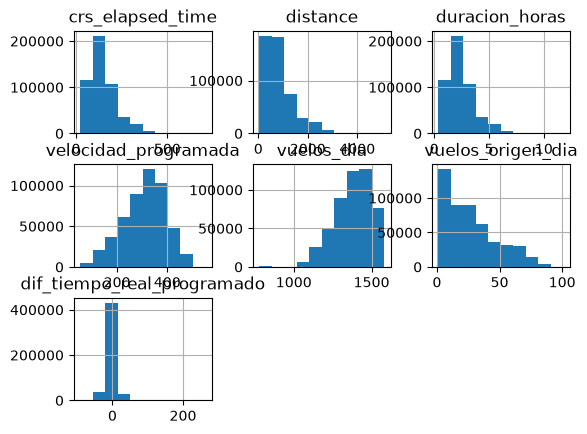

In [77]:
df_muestra[vard].hist()

<Axes: >

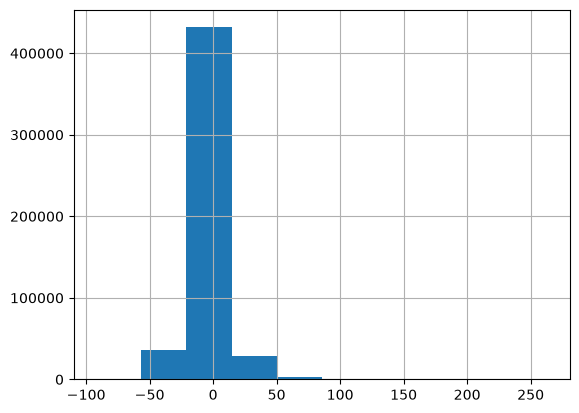

In [78]:
df_muestra['dif_tiempo_real_programado'].hist()

### Discretización

In [79]:
for v in vard:
    for k in range(3,7):
        # cuando k es mayor al número de valores únicos
        if df_muestra[v].nunique() < k:
            print(f"Saltando {v} con {k} bins porque tiene pocos valores únicos")
            continue
        
        print(f"Para la variable {v}, con {k} bins.")

        df_muestra = discretizar(df_muestra, v, k)

Para la variable crs_elapsed_time, con 3 bins.
Para la variable crs_elapsed_time, con 4 bins.
Para la variable crs_elapsed_time, con 5 bins.
Para la variable crs_elapsed_time, con 6 bins.
Para la variable distance, con 3 bins.
Para la variable distance, con 4 bins.
Para la variable distance, con 5 bins.
Para la variable distance, con 6 bins.
Para la variable duracion_horas, con 3 bins.
Para la variable duracion_horas, con 4 bins.
Para la variable duracion_horas, con 5 bins.
Para la variable duracion_horas, con 6 bins.
Para la variable velocidad_programada, con 3 bins.
Para la variable velocidad_programada, con 4 bins.
Para la variable velocidad_programada, con 5 bins.
Para la variable velocidad_programada, con 6 bins.
Para la variable vuelos_dia, con 3 bins.
Para la variable vuelos_dia, con 4 bins.
Para la variable vuelos_dia, con 5 bins.
Para la variable vuelos_dia, con 6 bins.
Para la variable vuelos_origen_dia, con 3 bins.
Para la variable vuelos_origen_dia, con 4 bins.
Para la vari

In [80]:
df_muestra.shape

(500000, 73)

In [81]:
df_muestra.head()

,index,year,month,day_of_month,day_of_week,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,crs_arr_time,crs_elapsed_time,distance,delay,temporada,momento_dia,es_fin_semana,dif_tiempo_real_programado,duracion_horas,velocidad_programada,vuelo_largo,vuelos_dia,vuelos_origen_dia,n_year,n_month,n_day_of_month,n_day_of_week,n_op_unique_carrier,n_op_carrier_fl_num,n_origin,n_origin_city_name,n_origin_state_nm,n_dest,n_dest_city_name,n_dest_state_nm,n_crs_dep_time,n_crs_arr_time,n_temporada,n_momento_dia,n_es_fin_semana,n_vuelo_largo,d_crs_elapsed_time_3,d_crs_elapsed_time_4,d_crs_elapsed_time_5,d_crs_elapsed_time_6,d_distance_3,d_distance_4,d_distance_5,d_distance_6,d_duracion_horas_3,d_duracion_horas_4,d_duracion_horas_5,d_duracion_horas_6,d_velocidad_programada_3,d_velocidad_programada_4,d_velocidad_programada_5,d_velocidad_programada_6,d_vuelos_dia_3,d_vuelos_dia_4,d_vuelos_dia_5,d_vuelos_dia_6,d_vuelos_origen_dia_3,d_vuelos_origen_dia_4,d_vuelos_origen_dia_5,d_vuelos_origen_dia_6,d_dif_tiempo_real_programado_3,d_dif_tiempo_real_programado_4,d_dif_tiempo_real_programado_5,d_dif_tiempo_real_programado_6
0,0,2024,4,18,4,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1900-01-01 10:18:00,11:49:00,151.0,835.0,0,Primavera,Mañana,0,-7.0,2.516667,331.788079,1,1427.0,64.0,2024,4,18,4,MQ,CAT_PEQUE,DFW,"Dallas/Fort Worth, TX",Texas,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,Primavera,Mañana,0,1,"(105.0, 160.0]","(130.0, 177.0]","(148.0, 191.0]","(130.0, 160.0]","(488.0, 944.0]","(680.0, 1069.0]","(577.0, 847.0]","(680.0, 944.0]","(1.75, 2.667]","(2.167, 2.95]","(2.467, 3.183]","(2.167, 2.667]","(278.298, 351.713]","(318.605, 369.091]","(295.556, 338.727]","(318.605, 351.713]","(1338.0, 1444.0]","(1391.0, 1469.0]","(1423.0, 1482.0]","(1391.0, 1444.0]","(32.0, 101.0]","(39.0, 101.0]","(45.0, 101.0]","(50.0, 101.0]","(-11.0, -3.0]","(-13.0, -7.0]","(-9.0, -5.0]","(-11.0, -7.0]"
1,1,2024,1,1,1,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1900-01-01 16:37:00,19:23:00,286.0,1773.0,0,Invierno,Tarde,0,-13.0,4.766667,371.958042,1,1265.0,41.0,2024,1,1,1,AA,CAT_PEQUE,CLT,"Charlotte, NC",North Carolina,CAT_PEQUE,CAT_PEQUE,Arizona,CAT_PEQUE,CAT_PEQUE,Invierno,Tarde,0,1,"(160.0, 707.0]","(177.0, 707.0]","(191.0, 707.0]","(205.0, 707.0]","(944.0, 5095.0]","(1069.0, 5095.0]","(1189.0, 5095.0]","(1303.0, 5095.0]","(2.667, 11.783]","(2.95, 11.783]","(3.183, 11.783]","(3.417, 11.783]","(351.713, 550.949]","(369.091, 550.949]","(338.727, 380.526]","(351.713, 389.31]","(776.999, 1338.0]","(776.999, 1305.0]","(776.999, 1276.0]","(1260.0, 1338.0]","(32.0, 101.0]","(39.0, 101.0]","(28.0, 45.0]","(32.0, 50.0]","(-92.001, -11.0]","(-92.001, -13.0]","(-15.0, -9.0]","(-16.0, -11.0]"
2,2,2024,12,12,4,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1900-01-01 10:00:00,10:59:00,59.0,106.0,0,Otoño,Mañana,0,-9.0,0.983333,107.796610,0,1370.0,3.0,2024,12,12,4,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,ATL,"Atlanta, GA",Georgia,CAT_PEQUE,CAT_PEQUE,Otoño,Mañana,0,0,"(21.999, 105.0]","(21.999, 94.0]","(21.999, 87.0]","(21.999, 84.0]","(30.999, 488.0]","(30.999, 399.0]","(30.999, 343.0]","(30.999, 311.0]","(0.366, 1.75]","(0.366, 1.567]","(0.366, 1.45]","(0.366, 1.4]","(52.207, 278.298]","(52.207, 252.857]","(52.207, 236.8]","(52.207, 222.759]","(1338.0, 1444.0]","(1305.0, 1391.0]","(1356.0, 1423.0]","(1338.0, 1391.0]","(0.999, 13.0]","(0.999, 9.0]","(0.999, 6.0]","(0.999, 5.0]","(-11.0, -3.0]","(-13.0, -7.0]","(-15.0, -9.0]","(-11.0, -7.0]"
3,3,2024,4,8,1,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1900-01-01 13:30:00,14:30:00,180.0,1099.0,0,Primavera,Tarde,0,-3.0,3.000000,366.333333,1,1455.0,4.0,2024,4,8,1,WN,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,Primavera,Tarde,0,1,"(160.0, 707.0]","(177.0, 707.0]","(148.0, 191.0]","(160.0, 205.0]","(944.0, 5095.

In [82]:
vari = [v for v in df_muestra.columns if v.startswith('d_')]

In [83]:
vari

['d_crs_elapsed_time_3',
 'd_crs_elapsed_time_4',
 'd_crs_elapsed_time_5',
 'd_crs_elapsed_time_6',
 'd_distance_3',
 'd_distance_4',
 'd_distance_5',
 'd_distance_6',
 'd_duracion_horas_3',
 'd_duracion_horas_4',
 'd_duracion_horas_5',
 'd_duracion_horas_6',
 'd_velocidad_programada_3',
 'd_velocidad_programada_4',
 'd_velocidad_programada_5',
 'd_velocidad_programada_6',
 'd_vuelos_dia_3',
 'd_vuelos_dia_4',
 'd_vuelos_dia_5',
 'd_vuelos_dia_6',
 'd_vuelos_origen_dia_3',
 'd_vuelos_origen_dia_4',
 'd_vuelos_origen_dia_5',
 'd_vuelos_origen_dia_6',
 'd_dif_tiempo_real_programado_3',
 'd_dif_tiempo_real_programado_4',
 'd_dif_tiempo_real_programado_5',
 'd_dif_tiempo_real_programado_6']

In [84]:
df_muestra[vari + varn].sample(10)

,d_crs_elapsed_time_3,d_crs_elapsed_time_4,d_crs_elapsed_time_5,d_crs_elapsed_time_6,d_distance_3,d_distance_4,d_distance_5,d_distance_6,d_duracion_horas_3,d_duracion_horas_4,d_duracion_horas_5,d_duracion_horas_6,d_velocidad_programada_3,d_velocidad_programada_4,d_velocidad_programada_5,d_velocidad_programada_6,d_vuelos_dia_3,d_vuelos_dia_4,d_vuelos_dia_5,d_vuelos_dia_6,d_vuelos_origen_dia_3,d_vuelos_origen_dia_4,d_vuelos_origen_dia_5,d_vuelos_origen_dia_6,d_dif_tiempo_real_programado_3,d_dif_tiempo_real_programado_4,d_dif_tiempo_real_programado_5,d_dif_tiempo_real_programado_6,n_month,n_day_of_month,n_day_of_week,n_op_unique_carrier,n_origin,n_origin_city_name,n_origin_state_nm,n_dest,n_dest_city_name,n_dest_state_nm,n_temporada,n_momento_dia,n_es_fin_semana,n_vuelo_largo
36156,"(21.999, 105.0]","(21.999, 94.0]","(21.999, 87.0]","(21.999, 84.0]","(30.999, 488.0]","(30.999, 399.0]","(30.999, 343.0]","(30.999, 311.0]","(0.366, 1.75]","(0.366, 1.567]","(0.366, 1.45]","(0.366, 1.4]","(52.207, 278.298]","(52.207, 252.857]","(52.207, 236.8]","(52.207, 222.759]","(1338.0, 1444.0]","(1391.0, 1469.0]","(1356.0, 1423.0]","(1391.0, 1444.0]","(13.0, 32.0]","(23.0, 39.0]","(17.0, 28.0]","(23.0, 32.0]","(-11.0, -3.0]","(-13.0, -7.0]","(-15.0, -9.0]","(-11.0, -7.0]",4,26,5,DL,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,Primavera,Noche,0,0
472908,"(105.0, 160.0]","(130.0, 177.0]","(115.0, 148.0]","(130.0, 160.0]","(488.0, 944.0]","(399.0, 680.0]","(577.0, 847.0]","(488.0, 680.0]","(1.75, 2.667]","(2.167, 2.95]","(1.917, 2.467]","(2.167, 2.667]","(278.298, 351.713]","(252.857, 318.605]","(236.8, 295.556]","(278.298, 318.605]","(1338.0, 1444.0]","(1305.0, 1391.0]","(1276.0, 1356.0]","(1338.0, 1391.0]","(32.0, 101.0]","(39.0, 101.0]","(45.0, 101.0]","(50.0, 101.0]","(-11.0, -3.0]","(-7.0, 0.0]","(-9.0, -5.0]","(-7.0, -3.0]",5,1,3,UA,DFW,"Dallas/Fort Worth, TX",Texas,DEN,"Denver, CO",Colorado,Primavera,Mañana,0,0
27579,"(21.999, 105.0]","(21.999, 94.0]","(87.0, 115.0]","(84.0, 105.0]","(30.999, 488.0]","(399.0, 680.0]","(343.0, 577.0]","(311.0, 488.0]","(0.366, 1.75]","(0.366, 1.567]","(1.45, 1.917]","(1.4, 1.75]","(278.298, 351.713]","(252.857, 318.605]","(236.8, 295.556]","(278.298, 318.605]","(1444.0, 1582.0]","(1469.0, 1582.0]","(1482.0, 1582.0]","(1444.0, 1496.0]","(13.0, 32.0]","(9.0, 23.0]","(6.0, 17.0]","(13.0, 23.0]","(-92.001, -11.0]","(-92.001, -13.0]","(-92.001, -15.0]","(-16.0, -11.0]",9,26,4,AA,CAT_PEQUE,CAT_PEQUE,North Carolina,CAT_PEQUE,"New York, NY",New York,Verano,Mañana,0,0
277897,"(105.0, 160.0]","(94.0, 130.0]","(87.0, 115.0]","(105.0, 130.0]","(30.999, 488.0]","(399.0, 680.0]","(343.0, 577.0]","(311.0, 488.0]","(1.75, 2.667]","(1.567, 2.167]","(1.45, 1.917]","(1.75, 2.167]","(52.207, 278.298]","(52.207, 252.857]","(52.207, 236.8]","(222.759, 278.298]","(1338.0, 1444.0]","(1391.0, 1469.0]","(1423.0, 1482.0]","(1391.0, 1444.0]","(13.0, 32.0]","(9.0, 23.0]","(6.0, 17.0]","(13.0, 23.0]","(-3.0, 263.0]","(0.0, 263.0]","(2.0, 263.0]","(4.0, 263.0]",8,1,4,YX,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,North Carolina,Verano,Noche,0,0
393888,"(160.0, 707.0]","(177.0, 707.0]","(191.0, 707.0]","(205.0, 707.0]","(944.0, 5095.0]","(1069.0, 5095.0]","(1189.0, 5095.0]","(1303.0, 5095.0]","(2.667, 11.783]","(2.95, 11.783]","(3.183, 11.783]","(3.417, 11.783]","(351.713, 550.949]","(369.091, 550.949]","(380.526, 550.949]","(389.31, 550.949]","(1444.0, 1582.0]","(1469.0, 1582.0]","(1482.0, 1582.0]","(1496.0, 1582.0]","(13.0, 32.0]","(23.0, 39.0]","(17.0, 28.0]","(23.0, 32.0]","(-3.0, 263.0]","(-7.0, 0.0]","(-5.0, 2.0]","(-3.0, 4.0]",12,1,7,DL,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,Florida,Otoño,Mañana,1,1
275796,"(160.0, 707.0]","(177.0, 707.0]","(191.0, 707.0]","(205.0, 707.0]","(944.0, 5095.0]","(1069.0, 5095.0]","(1189.0, 5095.0]","(1303.0, 5095.0]","(2.667, 11.783]","(2.95, 11.783]","(3.183, 11.783]","(3.417, 11.783]","(351.713, 550.949]","(369.091, 550.949]","(380.526, 550.949]","(389.31, 550.949]","(144

## Mejores variables 

### Discretizadas 

In [85]:
X = df_muestra[um + vari]
y = df_muestra[um + tgt]

In [86]:
from sklearn.model_selection import train_test_split


Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.3, random_state=1000)

In [87]:
Xt.shape, Xv.shape , yt.shape , yv.shape 

((350000, 29), (150000, 29), (350000, 2), (150000, 2))

### Calcular el IV

In [88]:
iv  = pd.DataFrame( map( lambda v: calculo_iv(df_muestra, v, tgt, um) , vari ) , columns=['variable','IV'] ).sort_values('IV',ascending=False)

In [89]:
iv.reset_index(drop=True)

,variable,IV
0,d_dif_tiempo_real_programado_6,0.522331
1,d_dif_tiempo_real_programado_5,0.466120
2,d_dif_tiempo_real_programado_4,0.412937
3,d_dif_tiempo_real_programado_3,0.326816
4,d_vuelos_dia_5,0.019472
5,d_vuelos_dia_6,0.019243
6,d_vuelos_dia_4,0.018194
7,d_vuelos_dia_3,0.017694
8,d_vuelos_origen_dia_6,0.013559
9,d_vuelos_origen_dia_3,0.013235


In [90]:
df_muestra[['delay','d_dif_tiempo_real_programado_6']].value_counts().reset_index()

,delay,d_dif_tiempo_real_programado_6,count
0,0,"(-92.001, -16.0]",80558
1,0,"(-11.0, -7.0]",76502
2,0,"(-16.0, -11.0]",72629
3,0,"(-3.0, 4.0]",66391
4,0,"(-7.0, -3.0]",60822
5,0,"(4.0, 263.0]",41098
6,1,"(4.0, 263.0]",40003
7,1,"(-3.0, 4.0]",15718
8,1,"(-92.001, -16.0]",12219
9,1,"(-11.0, -7.0]",11434


La variable dif_tiempo_real_programado presenta una capacidad relevante para diferenciar los registros con y sin retraso. Destaca particularmente el intervalo (4, 263], donde aproximadamente el 49.3% de las observaciones corresponden a delay=1, mientras que en los demás intervalos esta proporción se encuentra aproximadamente entre 13% y 19%. Esta diferencia evidencia que valores positivos superiores a 4 están fuertemente asociados con la ocurrencia de retrasos, lo cual explica el mayor poder predictivo observado mediante el IV.

In [91]:
df_muestra[['delay','d_crs_elapsed_time_4']].value_counts().reset_index()

,delay,d_crs_elapsed_time_4,count
0,0,"(21.999, 94.0]",103235
1,0,"(94.0, 130.0]",98935
2,0,"(177.0, 707.0]",98268
3,0,"(130.0, 177.0]",97562
4,1,"(177.0, 707.0]",26493
5,1,"(130.0, 177.0]",25928
6,1,"(94.0, 130.0]",24796
7,1,"(21.999, 94.0]",24783


In [92]:
iv['raiz'] = iv['variable'].map( lambda x: '_'.join(x.split('_')[1:-1] ) )
iv = iv.sort_values( by=['raiz','IV','variable'], ascending=[0,0,0] ).reset_index(drop=True)
iv = iv.sort_values( by=['raiz','IV','variable'], ascending=[0,0,0] ).reset_index(drop=True)
iv['id'] = iv.groupby(['raiz']).cumcount()+1
iv = iv[iv['id'] == 1].reset_index(drop=True)

In [93]:
iv.sort_values(['IV'],ascending=False).reset_index(drop=True)

,variable,IV,raiz,id
0,d_dif_tiempo_real_programado_6,0.522331,dif_tiempo_real_programado,1
1,d_vuelos_dia_5,0.019472,vuelos_dia,1
2,d_vuelos_origen_dia_6,0.013559,vuelos_origen_dia,1
3,d_velocidad_programada_5,0.004717,velocidad_programada,1
4,d_distance_5,0.004204,distance,1
5,d_duracion_horas_6,0.003191,duracion_horas,1
6,d_crs_elapsed_time_6,0.003191,crs_elapsed_time,1


In [94]:
besti = iv.sort_values(['IV'],ascending=False)

In [95]:
besti

,variable,IV,raiz,id
5,d_dif_tiempo_real_programado_6,0.522331,dif_tiempo_real_programado,1
1,d_vuelos_dia_5,0.019472,vuelos_dia,1
0,d_vuelos_origen_dia_6,0.013559,vuelos_origen_dia,1
2,d_velocidad_programada_5,0.004717,velocidad_programada,1
4,d_distance_5,0.004204,distance,1
3,d_duracion_horas_6,0.003191,duracion_horas,1
6,d_crs_elapsed_time_6,0.003191,crs_elapsed_time,1


## Normalizadas

In [96]:
iv2 = pd.DataFrame(  map( lambda v: calculo_iv( df_muestra, v, tgt, um ) , varn ), columns=['variable','IV']  )

In [97]:
iv2 = iv2.sort_values( by=['IV'], ascending=[0] ).reset_index(drop=True)

In [98]:
iv2

,variable,IV
0,n_momento_dia,0.153703
1,n_month,0.088456
2,n_op_unique_carrier,0.032297
3,n_temporada,0.031448
4,n_origin_state_nm,0.017385
5,n_origin_city_name,0.013299
6,n_origin,0.013084
7,n_day_of_week,0.012119
8,n_dest_state_nm,0.008514
9,n_dest_city_name,0.005991


Podemos observar que el momento del dia es una variable con un poder predictivo alto es decir que esta muy relacionada con los retrasos.

## Las mejores variables finales

In [99]:
iv = pd.concat([iv,iv2], ignore_index=True)

In [100]:
iv = iv[['variable','IV']].sort_values('IV',ascending=False).reset_index(drop=True)
iv = iv.loc[ (iv['IV']>0.005) & (iv['IV']<1.0)  ].reset_index(drop=True)


In [101]:
iv

,variable,IV
0,d_dif_tiempo_real_programado_6,0.522331
1,n_momento_dia,0.153703
2,n_month,0.088456
3,n_op_unique_carrier,0.032297
4,n_temporada,0.031448
5,d_vuelos_dia_5,0.019472
6,n_origin_state_nm,0.017385
7,d_vuelos_origen_dia_6,0.013559
8,n_origin_city_name,0.013299
9,n_origin,0.013084


In [102]:
best = iv['variable'].tolist()

In [103]:
best

['d_dif_tiempo_real_programado_6',
 'n_momento_dia',
 'n_month',
 'n_op_unique_carrier',
 'n_temporada',
 'd_vuelos_dia_5',
 'n_origin_state_nm',
 'd_vuelos_origen_dia_6',
 'n_origin_city_name',
 'n_origin',
 'n_day_of_week',
 'n_dest_state_nm',
 'n_dest_city_name',
 'n_dest']

## WoE

In [104]:
X = df_muestra[um + best ]
y = df_muestra[um + tgt ]
Xt, Xv , yt , yv = train_test_split(X, y, train_size=.7)

In [105]:
print(Xt.shape, Xv.shape , yt.shape , yv.shape )
Xt = Xt.merge(yt, on=um, how='inner').reset_index(drop=True)
print(Xt.shape, Xv.shape , yt.shape , yv.shape )

(350000, 15) (150000, 15) (350000, 2) (150000, 2)
(350000, 16) (150000, 15) (350000, 2) (150000, 2)


In [106]:
mapa_woe = list( map( lambda v: clasificacion_woe( Xt , v , tgt , um) , best ) )

In [107]:
mapa_woe

[('d_dif_tiempo_real_programado_6',
  {'(-11.0, -7.0]': 0.5315179603197584,
   '(-16.0, -11.0]': 0.50648396611894,
   '(-3.0, 4.0]': 0.07532332735363842,
   '(-7.0, -3.0]': 0.31158318061651635,
   '(-92.001, -16.0]': 0.5324346597966347,
   '(4.0, 263.0]': -1.3329487884688518}),
 ('n_momento_dia',
  {'Madrugada': 0.8662658084230734,
   'Mañana': 0.4783584617872795,
   'Noche': -0.44213817532167715,
   'Tarde': -0.181345208296316}),
 ('n_month',
  {'1': -0.16434764516714817,
   '10': 0.5373929296218648,
   '11': 0.43157151943092875,
   '12': -0.0027731132443203545,
   '2': 0.3179999728071109,
   '3': -0.02955622702058252,
   '4': 0.07608065732316197,
   '5': -0.3058333442224035,
   '6': -0.2370768580345608,
   '7': -0.43644924815467095,
   '8': -0.14529460384816031,
   '9': 0.3570587351679824}),
 ('n_op_unique_carrier',
  {'AA': -0.2934373159678044,
   'AS': -0.04934784372955386,
   'B6': -0.24677055085690358,
   'CAT_PEQUE': -0.03130697615350028,
   'DL': 0.22016554053380527,
   'MQ': -

In [108]:
Xt.shape , yt.shape

((350000, 16), (350000, 2))

In [109]:
for v, mapa in mapa_woe:
    Xt['w_'+v] = Xt[v].replace(mapa)
    Xv['w_'+v] = Xv[v].replace(mapa)

C:\Users\adria\AppData\Local\Temp\ipykernel_27492\485409377.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xt['w_'+v] = Xt[v].replace(mapa)
C:\Users\adria\AppData\Local\Temp\ipykernel_27492\485409377.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xv['w_'+v] = Xv[v].replace(mapa)
C:\Users\adria\AppData\Local\Temp\ipykernel_27492\485409377.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False

In [110]:
varw = Xt.filter(like='w_').columns.tolist()

In [111]:
len(best) , len(varw), varw

(14,
 14,
 ['w_d_dif_tiempo_real_programado_6',
  'w_n_momento_dia',
  'w_n_month',
  'w_n_op_unique_carrier',
  'w_n_temporada',
  'w_d_vuelos_dia_5',
  'w_n_origin_state_nm',
  'w_d_vuelos_origen_dia_6',
  'w_n_origin_city_name',
  'w_n_origin',
  'w_n_day_of_week',
  'w_n_dest_state_nm',
  'w_n_dest_city_name',
  'w_n_dest'])

## TAD

In [112]:
tad_t = Xt[um + varw ].merge( yt , on = um , how='inner' )
tad_v = Xv[um + varw ].merge( yv , on = um , how='inner' )

In [113]:
tad = pd.concat([tad_t, tad_v], ignore_index=True)

In [114]:
tad.shape

(500000, 16)

In [115]:
tad.head()

,index,w_d_dif_tiempo_real_programado_6,w_n_momento_dia,w_n_month,w_n_op_unique_carrier,w_n_temporada,w_d_vuelos_dia_5,w_n_origin_state_nm,w_d_vuelos_origen_dia_6,w_n_origin_city_name,w_n_origin,w_n_day_of_week,w_n_dest_state_nm,w_n_dest_city_name,w_n_dest,delay
0,351579,0.311583,-0.181345,0.076081,0.220166,-0.166460,0.168813,0.095689,-0.023343,0.046844,0.048329,0.141529,-0.159636,-0.013119,-0.007702,0
1,141532,-1.332949,-0.442138,-0.237077,-0.049518,-0.166460,-0.149256,0.095689,0.159463,0.046844,0.048329,0.009232,-0.118607,-0.111672,-0.111672,1
2,274086,0.311583,-0.181345,-0.436449,0.004904,-0.117261,-0.037800,0.099905,-0.094703,0.046844,0.048329,0.025126,-0.059309,-0.013119,-0.007702,0
3,278837,0.532435,-0.442138,-0.305833,0.220166,-0.166460,-0.037800,0.131133,-0.032874,0.124134,0.048329,0.173640,-0.059309,-0.013119,-0.007702,0
4,449637,0.075323,0.478358,-0.305833,-0.031307,-0.166460,0.168813,0.110808,0.159463,0.046844,0.048329,0.141529,0.036974,-0.013119,-0.007702,0


In [116]:
import pyarrow  

In [117]:
tad.to_parquet('tad_viajes.parquet')

# Módulo II – Modelación supervisada

## Objetivo del modelado

En esta etapa se utiliza la TAD construida en el Módulo I para desarrollar un problema de **clasificación binaria**. La variable objetivo `delay` toma el valor 0 cuando el vuelo no presenta retraso y 1 cuando presenta retraso.

Antes de entrenar los modelos se realiza un control explícito de **fuga de información (data leakage)**. La variable `dif_tiempo_real_programado` fue útil durante la exploración y presentó un IV elevado, pero utiliza `actual_elapsed_time`, un dato conocido después de que el vuelo ocurre. Por ello **no se utilizará como predictor del modelo**, ya que el objetivo es predecir el retraso con información disponible antes de la operación.

Debido a que la variable objetivo es binaria, la regresión lineal no es el modelo apropiado. Como alternativa lineal se utiliza **Regresión Logística**, y se compara contra un **Árbol de Decisión**, que permite representar relaciones no lineales entre las variables.


In [118]:
# Variables disponibles para el modelado
# Se parte de las variables WOE generadas en el Módulo I.
var_modelo = [
    c for c in tad_t.columns
    if c.startswith('w_')
    and 'dif_tiempo_real_programado' not in c
]

print('Variables utilizadas:', len(var_modelo))
print(var_modelo)


Variables utilizadas: 13
['w_n_momento_dia', 'w_n_month', 'w_n_op_unique_carrier', 'w_n_temporada', 'w_d_vuelos_dia_5', 'w_n_origin_state_nm', 'w_d_vuelos_origen_dia_6', 'w_n_origin_city_name', 'w_n_origin', 'w_n_day_of_week', 'w_n_dest_state_nm', 'w_n_dest_city_name', 'w_n_dest']


## División de entrenamiento y validación

La TAD ya fue dividida previamente en conjuntos de entrenamiento y validación. Para evitar utilizar información del conjunto de validación durante el entrenamiento, los modelos se ajustan únicamente con `tad_t` y se evalúan posteriormente sobre `tad_v`.

Se utiliza `class_weight='balanced'` porque la variable objetivo no está perfectamente balanceada: en la muestra de 500,000 registros se observaron 398,000 vuelos sin retraso y 102,000 con retraso.


In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import numpy as np

X_train = tad_t[var_modelo].replace([np.inf, -np.inf], np.nan).fillna(0)
X_valid = tad_v[var_modelo].replace([np.inf, -np.inf], np.nan).fillna(0)

y_train = tad_t[tgt[0]]
y_valid = tad_v[tgt[0]]

print('Train:', X_train.shape)
print('Validación:', X_valid.shape)
print('Proporción positiva train:', y_train.mean())
print('Proporción positiva validación:', y_valid.mean())


Train: (350000, 13)
Validación: (150000, 13)
Proporción positiva train: 0.20354
Proporción positiva validación: 0.20507333333333333


## Modelo 1 – Regresión Logística

La regresión logística es adecuada para clasificación binaria y permite estimar la probabilidad de que un vuelo pertenezca a la clase `delay=1`. Además, sus coeficientes permiten interpretar la dirección de la relación entre las variables WOE y la probabilidad estimada.


In [120]:
modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

modelo_logistico.fit(X_train, y_train)

proba_log = modelo_logistico.predict_proba(X_valid)[:, 1]
pred_log = (proba_log >= 0.50).astype(int)


## Modelo 2 – Árbol de Decisión

El árbol de decisión permite capturar relaciones no lineales y reglas de interacción entre las variables. Se limita la profundidad y el número mínimo de observaciones por hoja para reducir el riesgo de sobreajuste y facilitar la interpretación.


In [121]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

proba_tree = modelo_arbol.predict_proba(X_valid)[:, 1]
pred_tree = (proba_tree >= 0.50).astype(int)


## Evaluación y comparación

Debido a que el objetivo es identificar vuelos que presentarán retraso, no se considera suficiente utilizar únicamente accuracy. Se revisan **precision, recall, F1 y ROC-AUC**, además de la matriz de confusión.

- **Recall:** proporción de vuelos retrasados que el modelo logra identificar.
- **Precision:** proporción de predicciones de retraso que efectivamente corresponden a vuelos retrasados.
- **F1:** equilibrio entre precision y recall.
- **ROC-AUC:** capacidad de discriminación entre ambas clases a diferentes umbrales.

Para el caso de negocio, el recall y el F1 son especialmente relevantes si se busca identificar la mayor cantidad posible de vuelos con riesgo de retraso.


In [122]:
def evaluar_modelo(nombre, y_true, pred, proba):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, proba)
    }

resultados_modelos = pd.DataFrame([
    evaluar_modelo('Regresión Logística', y_valid, pred_log, proba_log),
    evaluar_modelo('Árbol de Decisión', y_valid, pred_tree, proba_tree)
]).sort_values('f1', ascending=False)

display(resultados_modelos)


,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión Logística,0.604727,0.286260,0.621079,0.391893,0.650987
1,Árbol de Decisión,0.648787,0.299262,0.531192,0.382840,0.645690


In [123]:
# Matrices de confusión
print('Matriz de confusión – Regresión Logística')
display(pd.DataFrame(
    confusion_matrix(y_valid, pred_log),
    index=['Real 0', 'Real 1'],
    columns=['Pred 0', 'Pred 1']
))

print('Matriz de confusión – Árbol de Decisión')
display(pd.DataFrame(
    confusion_matrix(y_valid, pred_tree),
    index=['Real 0', 'Real 1'],
    columns=['Pred 0', 'Pred 1']
))


Matriz de confusión – Regresión Logística


,Pred 0,Pred 1
Real 0,71604,47635
Real 1,11656,19105


Matriz de confusión – Árbol de Decisión


,Pred 0,Pred 1
Real 0,80978,38261
Real 1,14421,16340


## Selección del modelo

El modelo final se seleccionará con base en el comportamiento observado en el conjunto de validación. Como criterio principal se considera el **F1**, complementado por recall, precision y ROC-AUC.

No se establece un ganador antes de ejecutar el notebook: la selección se realiza a partir de los resultados obtenidos. Esto evita elegir un modelo por anticipado y permite justificar la decisión con evidencia cuantitativa.


In [124]:
modelo_final = resultados_modelos.iloc[0]['modelo']
print('Modelo seleccionado por F1:', modelo_final)


Modelo seleccionado por F1: Regresión Logística


## Interpretabilidad

Para complementar la evaluación se revisan los coeficientes de la regresión logística y la importancia de variables del árbol. Estas salidas permiten identificar qué características contribuyen con mayor fuerza a la clasificación y facilitan la explicación de los resultados al público de negocio.


In [125]:
# Importancia de variables del árbol
importancias_arbol = (
    pd.DataFrame({
        'variable': var_modelo,
        'importance': modelo_arbol.feature_importances_
    })
    .sort_values('importance', ascending=False)
)

display(importancias_arbol.head(15))

# Coeficientes de la regresión logística
coef_log = (
    pd.DataFrame({
        'variable': var_modelo,
        'coeficiente': modelo_logistico.coef_[0]
    })
    .sort_values('coeficiente', ascending=False)
)

display(coef_log.head(15))


,variable,importance
0,w_n_momento_dia,0.512299
1,w_n_month,0.280819
2,w_n_op_unique_carrier,0.114931
9,w_n_day_of_week,0.037833
4,w_d_vuelos_dia_5,0.019319
5,w_n_origin_state_nm,0.015231
10,w_n_dest_state_nm,0.012809
3,w_n_temporada,0.004274
6,w_d_vuelos_origen_dia_6,0.002486
8,w_n_origin,0.000000


,variable,coeficiente
8,w_n_origin,0.072093
3,w_n_temporada,0.065791
11,w_n_dest_city_name,0.052896
7,w_n_origin_city_name,0.006484
12,w_n_dest,-0.002205
4,w_d_vuelos_dia_5,-0.304354
6,w_d_vuelos_origen_dia_6,-0.474254
5,w_n_origin_state_nm,-0.543001
10,w_n_dest_state_nm,-0.629691
2,w_n_op_unique_carrier,-0.859615
